In [34]:
!pip install lightgbm

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
)

# try to import LightGBM
try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
    print(
        "WARNING: lightgbm is not installed. "
        "Only Logistic Regression will be used. "
        "Install via 'pip install lightgbm' if you want to enable it."
    )


In [36]:
CSV_PATH = "creditcard.csv"
REVENUE_LEGIT = 1.0     
COST_FRAUD = 10.0     
COST_CHALLENGE = 0.2   
COST_BLOCK = 1.0         


Time-based split:
  Train: 170884 rows
  Valid: 56961 rows
  Test : 56962 rows

Feature matrix shapes (after scaling):
  X_train: (170884, 30)
  X_val  : (56961, 30)
  X_test : (56962, 30)

Training Logistic Regression...

Training LightGBM...
[LightGBM] [Info] Number of positive: 360, number of negative: 170524
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016287 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 170884, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.002107 -> initscore=-6.160527
[LightGBM] [Info] Start training from score -6.160527
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spli

c:\anaconda\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



[valid (LightGBM)] ROC-AUC: 0.6996, PR-AUC: 0.0356

Best model selected based on validation PR-AUC: Logistic Regression

Fitting Platt scaler on validation set...

[Test] metrics using calibrated Logistic Regression probabilities:
  ROC-AUC: 0.9820
  PR-AUC : 0.7436

Classification report at threshold=0.50:
              precision    recall  f1-score   support

           0     0.9987    1.0000    0.9993     56887
           1     0.0000    0.0000    0.0000        75

    accuracy                         0.9987     56962
   macro avg     0.4993    0.5000    0.4997     56962
weighted avg     0.9974    0.9987    0.9980     56962

Confusion matrix (rows: true [0,1], cols: pred [0,1]):
[[56887     0]
 [   75     0]]


c:\anaconda\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\anaconda\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\anaconda\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


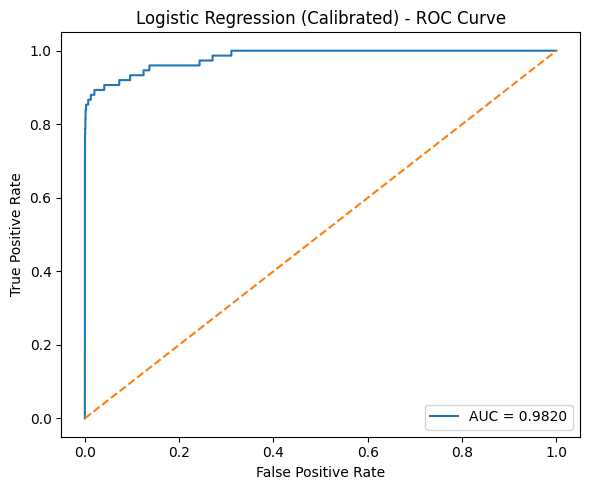

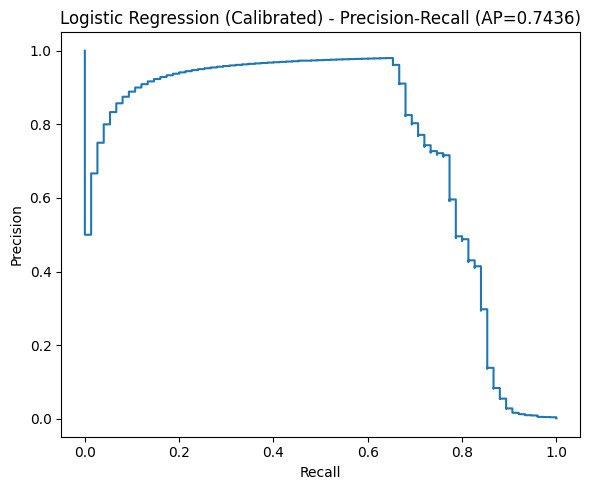


Searching best (tau1, tau2) thresholds for profit...

Best thresholds for profit:
  tau1 (Approve/Step-up boundary): 0.0833
  tau2 (Step-up/Decline boundary): 0.1250
  Max avg profit per transaction  : 0.9959
  Approve rate : 99.73%
  Challenge rate: 0.27%
  Decline rate : 0.00%

Treating 'Step-up or Decline' as positive prediction (flagged as fraud):
              precision    recall  f1-score   support

           0     0.9998    0.9984    0.9991     56887
           1     0.4106    0.8267    0.5487        75

    accuracy                         0.9982     56962
   macro avg     0.7052    0.9126    0.7739     56962
weighted avg     0.9990    0.9982    0.9985     56962

Confusion matrix (rows: true [0,1], cols: pred [0,1]):
[[56798    89]
 [   13    62]]


In [37]:
CSV_PATH = "creditcard.csv"
REVENUE_LEGIT = 1.0      
COST_FRAUD = 10.0        
COST_CHALLENGE = 0.2     
COST_BLOCK = 1.0        
def load_dataset(path: str) -> pd.DataFrame:
    """读取 Kaggle creditcard.csv，并打印基本信息。"""
    df = pd.read_csv(path)
    print("Raw data shape:", df.shape)
    print("\nClass balance (0=legit, 1=fraud):")
    print(df["Class"].value_counts())
    print("\nClass ratio:")
    print(df["Class"].value_counts(normalize=True))
    return df

def basic_cleaning(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if df.isna().any().any():
        print("Missing values detected, filling with column medians...")
        df = df.fillna(df.median(numeric_only=True))
    return df

def time_based_split(
    df: pd.DataFrame,
    time_col: str = "Time",
    label_col: str = "Class",
    train_frac: float = 0.6,
    val_frac: float = 0.2,
    test_frac: float = 0.2,
):
    assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-6, "fractions must sum to 1"

    df_sorted = df.sort_values(time_col).reset_index(drop=True)
    n = len(df_sorted)
    train_end = int(n * train_frac)
    val_end = int(n * (train_frac + val_frac))

    train_df = df_sorted.iloc[:train_end].reset_index(drop=True)
    val_df = df_sorted.iloc[train_end:val_end].reset_index(drop=True)
    test_df = df_sorted.iloc[val_end:].reset_index(drop=True)

    print(f"\nTime-based split:")
    print(f"  Train: {train_df.shape[0]} rows")
    print(f"  Valid: {val_df.shape[0]} rows")
    print(f"  Test : {test_df.shape[0]} rows")

    return train_df, val_df, test_df

def build_feature_matrices(train_df, val_df, test_df, label_col="Class"):
    feature_cols = [c for c in train_df.columns if c != label_col]

    X_train = train_df[feature_cols].values
    y_train = train_df[label_col].values

    X_val = val_df[feature_cols].values
    y_val = val_df[label_col].values

    X_test = test_df[feature_cols].values
    y_test = test_df[label_col].values

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    print("\nFeature matrix shapes (after scaling):")
    print("  X_train:", X_train_scaled.shape)
    print("  X_val  :", X_val_scaled.shape)
    print("  X_test :", X_test_scaled.shape)

    return (
        X_train_scaled,
        y_train,
        X_val_scaled,
        y_val,
        X_test_scaled,
        y_test,
        feature_cols,
        scaler,
    )

def train_logistic(X_train, y_train):
    print("\nTraining Logistic Regression...")
    log_reg = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1,
        solver="lbfgs",
    )
    log_reg.fit(X_train, y_train)
    return log_reg

def train_lgbm(X_train, y_train):
    if not HAS_LGBM:
        return None

    print("\nTraining LightGBM...")
    n_pos = np.sum(y_train)
    n_neg = len(y_train) - n_pos
    scale_pos_weight = n_neg / n_pos

    lgbm = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary",
        scale_pos_weight=scale_pos_weight,
        n_jobs=-1,
        random_state=42,
    )
    lgbm.fit(X_train, y_train)
    return lgbm

def evaluate_model(model, X, y, set_name="valid"):
    prob = model.predict_proba(X)[:, 1]
    roc = roc_auc_score(y, prob)
    pr_auc = average_precision_score(y, prob)

    print(f"\n[{set_name}] ROC-AUC: {roc:.4f}, PR-AUC: {pr_auc:.4f}")
    return prob, roc, pr_auc


def fit_platt_scaler(probs_val, y_val):
    print("\nFitting Platt scaler on validation set...")
    lr = LogisticRegression(solver="lbfgs")
    X_cal = probs_val.reshape(-1, 1)
    lr.fit(X_cal, y_val)
    return lr

def apply_calibration(calibrator, probs):
    X_cal = probs.reshape(-1, 1)       # (n_samples, 1)
    return calibrator.predict_proba(X_cal)[:, 1]
def plot_curves(y_true, probs, title_prefix="Model",
                save_roc=None, save_pr=None):
    # ROC 
    fpr, tpr, _ = roc_curve(y_true, probs)
    roc_auc = roc_auc_score(y_true, probs)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title_prefix} - ROC Curve")
    plt.legend()
    plt.tight_layout()

    if save_roc is not None:
        plt.savefig(save_roc, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close()

    # PR
    precision, recall, _ = precision_recall_curve(y_true, probs)
    pr_auc = average_precision_score(y_true, probs)

    plt.figure(figsize=(6, 5))
    plt.step(recall, precision, where="post")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title_prefix} - Precision-Recall (AP={pr_auc:.4f})")
    plt.tight_layout()

    if save_pr is not None:
        plt.savefig(save_pr, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close()

def search_best_thresholds(
    y_true,
    probs,
    R=REVENUE_LEGIT,
    C_fraud=COST_FRAUD,
    C_challenge=COST_CHALLENGE,
    C_block=COST_BLOCK,
    n_grid=25,
):
    print("\nSearching best (tau1, tau2) thresholds for profit...")

    y_true = np.asarray(y_true)
    probs = np.asarray(probs)

    n = len(y_true)
    non_fraud = (y_true == 0)
    fraud = ~non_fraud

    taus = np.linspace(0.0, 1.0, n_grid)

    best = {
        "profit": -np.inf,
        "tau1": None,
        "tau2": None,
        "approve_rate": None,
        "challenge_rate": None,
        "decline_rate": None,
    }

    for tau1 in taus:
        for tau2 in taus:
            if tau2 < tau1:
                continue

            approve = probs < tau1
            challenge = (probs >= tau1) & (probs < tau2)
            decline = probs >= tau2

            n_app_nf = np.sum(approve & non_fraud)
            n_app_fr = np.sum(approve & fraud)

            n_ch_nf = np.sum(challenge & non_fraud)
            n_ch_fr = np.sum(challenge & fraud)

            n_dec_nf = np.sum(decline & non_fraud)
            n_dec_fr = np.sum(decline & fraud)

            profit = (
                n_app_nf * R
                + n_ch_nf * (R - C_challenge)
                - n_dec_nf * C_block
                - n_app_fr * C_fraud
                - (n_ch_fr + 0 * n_dec_fr) * C_challenge
            )

            avg_profit = profit / n

            if avg_profit > best["profit"]:
                best["profit"] = avg_profit
                best["tau1"] = tau1
                best["tau2"] = tau2
                best["approve_rate"] = np.mean(approve)
                best["challenge_rate"] = np.mean(challenge)
                best["decline_rate"] = np.mean(decline)

    print("\nBest thresholds for profit:")
    print(f"  tau1 (Approve/Step-up boundary): {best['tau1']:.4f}")
    print(f"  tau2 (Step-up/Decline boundary): {best['tau2']:.4f}")
    print(f"  Max avg profit per transaction  : {best['profit']:.4f}")
    print(f"  Approve rate : {best['approve_rate']:.2%}")
    print(f"  Challenge rate: {best['challenge_rate']:.2%}")
    print(f"  Decline rate : {best['decline_rate']:.2%}")

    return best


def evaluate_at_threshold(y_true, probs, threshold=0.5):
    y_pred = (probs >= threshold).astype(int)

    print(f"\nClassification report at threshold={threshold:.2f}:")
    print(classification_report(y_true, y_pred, digits=4))

    print("Confusion matrix (rows: true [0,1], cols: pred [0,1]):")
    print(confusion_matrix(y_true, y_pred))

# main procee

def main():
    df = pd.read_csv(CSV_PATH)
    df = basic_cleaning(df)
    train_df, val_df, test_df = time_based_split(df)

    (
        X_train,
        y_train,
        X_val,
        y_val,
        X_test,
        y_test,
        feature_cols,
        scaler,
    ) = build_feature_matrices(train_df, val_df, test_df)
    log_reg = train_logistic(X_train, y_train)

    if HAS_LGBM:
        lgbm = train_lgbm(X_train, y_train)
    else:
        lgbm = None

    log_val_probs, log_val_roc, log_val_pr = evaluate_model(
        log_reg, X_val, y_val, set_name="valid (Logistic)"
    )

    best_model = log_reg
    best_name = "Logistic Regression"
    best_val_probs = log_val_probs
    best_val_pr = log_val_pr

    if lgbm is not None:
        lgb_val_probs, lgb_val_roc, lgb_val_pr = evaluate_model(
            lgbm, X_val, y_val, set_name="valid (LightGBM)"
        )
        if lgb_val_pr > best_val_pr:
            best_model = lgbm
            best_name = "LightGBM"
            best_val_probs = lgb_val_probs
            best_val_pr = lgb_val_pr

    print(f"\nBest model selected based on validation PR-AUC: {best_name}")
    #platt calibration
    platt_scaler = fit_platt_scaler(best_val_probs, y_val)

    raw_test_probs = best_model.predict_proba(X_test)[:, 1]
    test_probs = apply_calibration(platt_scaler, raw_test_probs)

    print(f"\n[Test] metrics using calibrated {best_name} probabilities:")
    test_roc = roc_auc_score(y_test, test_probs)
    test_pr = average_precision_score(y_test, test_probs)
    print(f"  ROC-AUC: {test_roc:.4f}")
    print(f"  PR-AUC : {test_pr:.4f}")

    evaluate_at_threshold(y_test, test_probs, threshold=0.5)

    # 8. plot ROC & PR 
    plot_curves(
    y_test,
    test_probs,
    title_prefix=f"{best_name} (Calibrated)",
    save_roc=r"C:\Users\GuoJJ\OneDrive\Desktop\stats507\roc_curve.png",
    save_pr=r"C:\Users\GuoJJ\OneDrive\Desktop\stats507\pr_curve.png",
    )

    
    # 9. maximize average profit
    best_thresholds = search_best_thresholds(y_test, test_probs)

    tau1 = best_thresholds["tau1"]
    tau2 = best_thresholds["tau2"]
    flags = (test_probs >= tau1) 
    y_pred_flag = flags.astype(int)

    print("\nTreating 'Step-up or Decline' as positive prediction (flagged as fraud):")
    print(classification_report(y_test, y_pred_flag, digits=4))
    print("Confusion matrix (rows: true [0,1], cols: pred [0,1]):")
    print(confusion_matrix(y_test, y_pred_flag))


if __name__ == "__main__":
    main()